# Airbnb NYC 2019 — Nightly Price Prediction
**DS444 Team Project — Phase II**

**Problem:** Predict the nightly price of an Airbnb listing in New York City.

**Why it matters:** Hosts need data-driven pricing guidance. Guests benefit from knowing whether a listing is fairly priced.

**Outcome variable:** `price` — nightly price in USD (continuous, numeric)

**Dataset:** NYC Airbnb Open Data 2019 — 48,017 listings after cleaning.

**Approach:**
- Compare 7 regression models across all major ML families
- Use 5-fold cross-validation for reliable model selection
- Evaluate on a held-out test set for honest final performance
- Report all metrics in original price units

---
## Step 1 — Imports

In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer

from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

plt.style.use('seaborn-v0_8')
pd.set_option('display.float_format', '{:.2f}'.format)

SEED     = 42
CV_FOLDS = 5

---
## Step 2 — Load and Inspect Data

In [2]:
df = pd.read_csv('AB_NYC_2019_cleaned.csv')
print(f'Shape: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head()

Shape: 48,017 rows x 16 columns


,id,name,host_id,host_name,neighbourhood_group,neighbourhood,latitude,longitude,room_type,price,minimum_nights,number_of_reviews,last_review,reviews_per_month,calculated_host_listings_count,availability_365
0,2539,Clean & quiet apt home by the park,2787,John,Brooklyn,Kensington,40.65,-73.97,Private room,149,1,9,2018-10-19,0.21,6,365
1,2595,Skylit Midtown Castle,2845,Jennifer,Manhattan,Midtown,40.75,-73.98,Entire home/apt,225,1,45,2019-05-21,0.38,2,355
2,3647,THE VILLAGE OF HARLEM....NEW YORK !,4632,Elisabeth,Manhattan,Harlem,40.81,-73.94,Private room,150,3,0,NaN,0.00,1,365
3,3831,Cozy Entire Floor of Brownstone,4869,LisaRoxanne,Brooklyn,Clinton Hill,40.69,-73.96,Entire home/apt,89,1,270,2019-07-05,4.64,1,194
4,5022,Entire Apt: Spacious Studio/Loft by central park,7192,Laura,Manhattan,East Harlem,40.80,-73.94,Entire home/apt,80,10,9,2018-11-19,0.10,1,0


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 48017 entries, 0 to 48016
Data columns (total 16 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              48017 non-null  int64  
 1   name                            48001 non-null  str    
 2   host_id                         48017 non-null  int64  
 3   host_name                       47997 non-null  str    
 4   neighbourhood_group             48017 non-null  str    
 5   neighbourhood                   48017 non-null  str    
 6   latitude                        48017 non-null  float64
 7   longitude                       48017 non-null  float64
 8   room_type                       48017 non-null  str    
 9   price                           48017 non-null  int64  
 10  minimum_nights                  48017 non-null  int64  
 11  number_of_reviews               48017 non-null  int64  
 12  last_review                     38283 non-n

In [4]:
df.describe()

,id,host_id,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365
count,48017.00,48017.00,48017.00,48017.00,48017.00,48017.00,48017.00,48017.00,48017.00,48017.00
mean,18976512.73,67295777.56,40.73,-73.95,138.50,6.97,23.47,1.10,7.20,112.07
std,10980074.04,78464064.77,0.05,0.05,103.69,20.30,44.78,1.60,33.21,131.22
min,2539.00,2438.00,40.50,-74.24,30.00,1.00,0.00,0.00,1.00,0.00
25%,9437085.00,7755859.00,40.69,-73.98,70.00,1.00,1.00,0.04,1.00,0.00
50%,19621042.00,30532557.00,40.72,-73.96,105.00,3.00,5.00,0.38,1.00,44.00
75%,29096185.00,107417836.00,40.76,-73.94,175.00,5.00,24.00,1.60,2.00,224.00
max,36487245.00,274321313.00,40.91,-73.71,799.00,1250.00,629.00,58.50,327.00,365.00


In [5]:
print('Missing values per column:')
print(df.isna().sum())

Missing values per column:
id                                   0
name                                16
host_id                              0
host_name                           20
neighbourhood_group                  0
neighbourhood                        0
latitude                             0
longitude                            0
room_type                            0
price                                0
minimum_nights                       0
number_of_reviews                    0
last_review                       9734
reviews_per_month                    0
calculated_host_listings_count       0
availability_365                     0
dtype: int64


---
## Step 3 — Exploratory Data Analysis

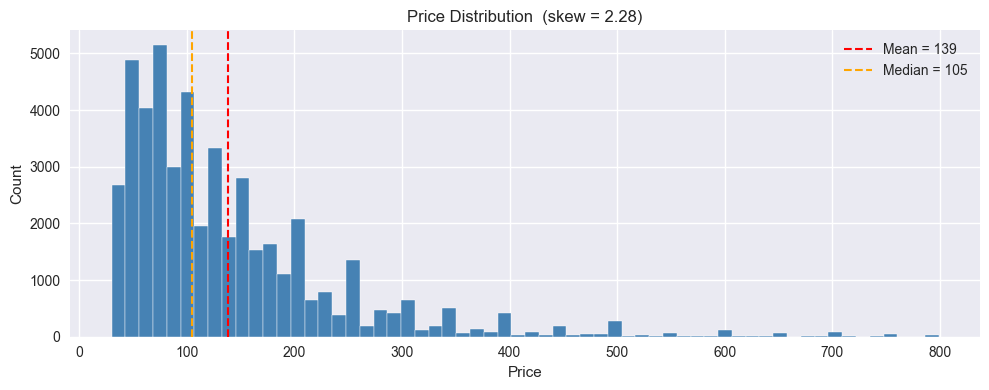

Price range : 30 — 799
Mean price  : 138.50
Median price: 105.00


In [6]:
# Price distribution
fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(df['price'], bins=60, color='steelblue', edgecolor='white')
ax.axvline(df['price'].mean(),   color='red',    ls='--', lw=1.5,
           label=f"Mean = {df['price'].mean():.0f}")
ax.axvline(df['price'].median(), color='orange', ls='--', lw=1.5,
           label=f"Median = {df['price'].median():.0f}")
ax.set_title(f"Price Distribution  (skew = {df['price'].skew():.2f})", fontsize=12)
ax.set_xlabel('Price')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()
print(f'Price range : {df["price"].min()} — {df["price"].max()}')
print(f'Mean price  : {df["price"].mean():.2f}')
print(f'Median price: {df["price"].median():.2f}')

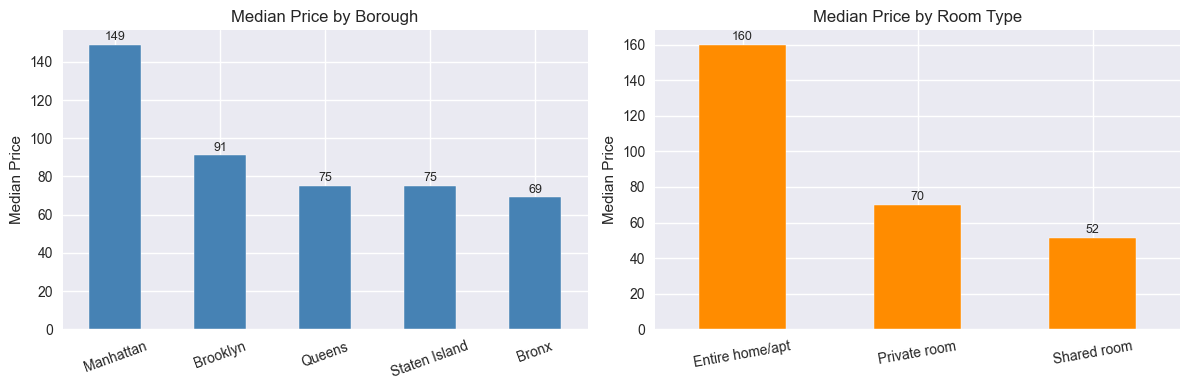

In [7]:
# Median price by Borough and Room Type
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

boro = df.groupby('neighbourhood_group')['price'].median().sort_values(ascending=False)
boro.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Median Price by Borough', fontsize=12)
axes[0].set_xlabel('')
axes[0].set_ylabel('Median Price')
axes[0].tick_params(axis='x', rotation=20)
for p in axes[0].patches:
    axes[0].text(p.get_x() + p.get_width()/2, p.get_height() + 1,
                 f'{p.get_height():.0f}', ha='center', va='bottom', fontsize=9)

room = df.groupby('room_type')['price'].median().sort_values(ascending=False)
room.plot(kind='bar', ax=axes[1], color='darkorange', edgecolor='white')
axes[1].set_title('Median Price by Room Type', fontsize=12)
axes[1].set_xlabel('')
axes[1].set_ylabel('Median Price')
axes[1].tick_params(axis='x', rotation=10)
for p in axes[1].patches:
    axes[1].text(p.get_x() + p.get_width()/2, p.get_height() + 1,
                 f'{p.get_height():.0f}', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

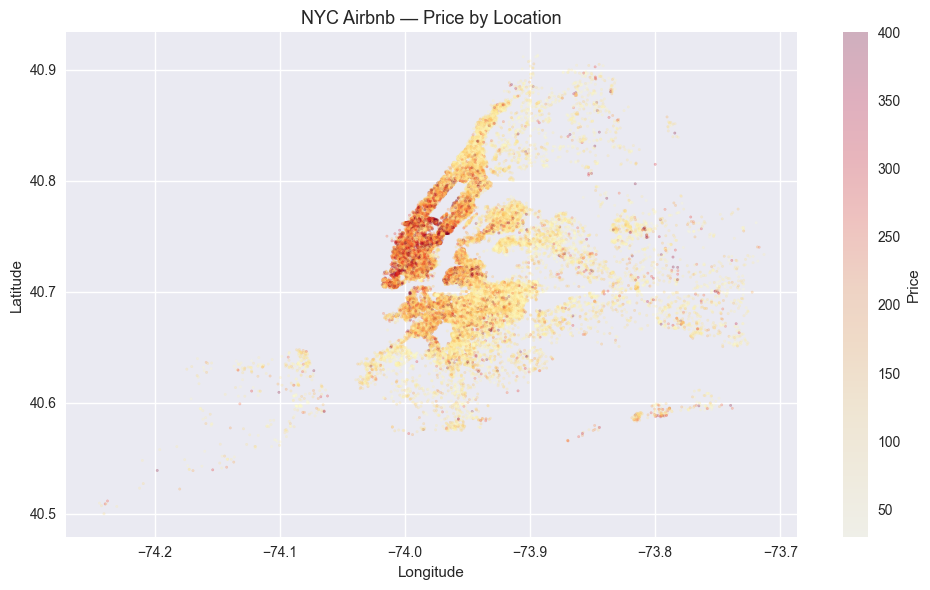

In [9]:
# Geographic price map
plt.figure(figsize=(10, 6))
sc = plt.scatter(
    df['longitude'], df['latitude'],
    c=df['price'], cmap='YlOrRd',
    alpha=0.25, s=3, vmax=400
)
plt.colorbar(sc, label='Price')
plt.title('NYC Airbnb — Price by Location', fontsize=13)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.tight_layout()
plt.show()

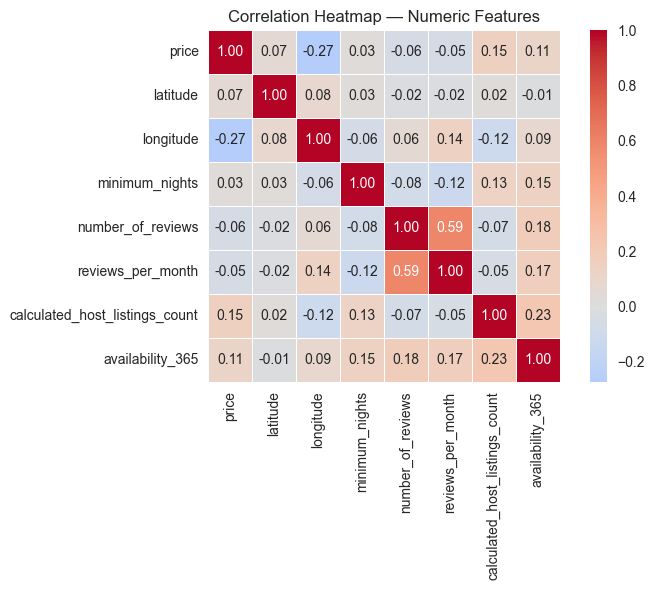

In [10]:
# Correlation heatmap
num_cols = ['price', 'latitude', 'longitude', 'minimum_nights',
            'number_of_reviews', 'reviews_per_month',
            'calculated_host_listings_count', 'availability_365']

plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols].corr(), annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True, linewidths=0.5)
plt.title('Correlation Heatmap — Numeric Features', fontsize=12)
plt.tight_layout()
plt.show()

---
## Step 4 — Feature Selection

**Columns dropped:**

| Column | Reason |
|---|---|
| `id`, `host_id` | Random identifiers — no predictive value |
| `name`, `host_name` | Free text — cannot use directly |
| `last_review` | Date string — not useful without feature engineering |
| `neighbourhood` | 200+ unique values — too granular, causes noise |

**Features kept (9 total):**

| Feature | Type | Why |
|---|---|---|
| `latitude`, `longitude` | Numeric | Location drives price strongly |
| `minimum_nights` | Numeric | Reflects listing type |
| `number_of_reviews` | Numeric | Proxy for popularity |
| `reviews_per_month` | Numeric | Proxy for demand |
| `calculated_host_listings_count` | Numeric | Professional vs casual host |
| `availability_365` | Numeric | How available the listing is |
| `neighbourhood_group` | Categorical | Borough — only 5 values, clean |
| `room_type` | Categorical | Biggest driver of price |

**Target: raw `price` — no transformation needed.**
Training directly on raw price means residuals stay genuinely near zero and metrics are directly interpretable in price units.

In [11]:
NUMERIC_FEATURES = [
    'latitude', 'longitude', 'minimum_nights',
    'number_of_reviews', 'reviews_per_month',
    'calculated_host_listings_count', 'availability_365'
]

CATEGORICAL_FEATURES = ['neighbourhood_group', 'room_type']

ALL_FEATURES = NUMERIC_FEATURES + CATEGORICAL_FEATURES

X = df[ALL_FEATURES]
y = df['price']

print(f'Features  : {len(ALL_FEATURES)}')
print(f'  Numeric     ({len(NUMERIC_FEATURES)}): {NUMERIC_FEATURES}')
print(f'  Categorical ({len(CATEGORICAL_FEATURES)}): {CATEGORICAL_FEATURES}')
print(f'\nTarget    : price')
print(f'  Mean   : {y.mean():.2f}')
print(f'  Median : {y.median():.2f}')
print(f'  Std    : {y.std():.2f}')
print(f'  Range  : {y.min()} — {y.max()}')

Features  : 9
  Numeric     (7): ['latitude', 'longitude', 'minimum_nights', 'number_of_reviews', 'reviews_per_month', 'calculated_host_listings_count', 'availability_365']
  Categorical (2): ['neighbourhood_group', 'room_type']

Target    : price
  Mean   : 138.50
  Median : 105.00
  Std    : 103.69
  Range  : 30 — 799


---
## Step 5 — Train / Test Split

80% training, 20% test. The test set is never touched during training or cross-validation.

In [12]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=SEED
)

print(f'Training set : {len(X_train):,} rows (80%)')
print(f'Test set     : {len(X_test):,} rows (20%)')
print(f'Train price  : mean={y_train.mean():.2f}, std={y_train.std():.2f}')
print(f'Test  price  : mean={y_test.mean():.2f},  std={y_test.std():.2f}')

Training set : 38,413 rows (80%)
Test set     : 9,604 rows (20%)
Train price  : mean=138.45, std=103.61
Test  price  : mean=138.71,  std=104.02


---
## Step 6 — Preprocessing Pipeline

All preprocessing is inside `sklearn.Pipeline` to prevent **data leakage**. Scalers and encoders fit only on training data and are applied to test data without seeing it.

| Feature type | Imputation | Encoding |
|---|---|---|
| Numeric | Median | StandardScaler |
| Categorical | Most frequent | OneHotEncoder |

In [13]:
preprocessor = ColumnTransformer([
    ('num', Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler())
    ]), NUMERIC_FEATURES),

    ('cat', Pipeline([
        ('imputer', SimpleImputer(strategy='most_frequent')),
        ('encoder', OneHotEncoder(handle_unknown='ignore'))
    ]), CATEGORICAL_FEATURES),
])


---
## Step 7 — Define Models

We compare 7 models covering all major regression families:

| Model | Family | Key idea |
|---|---|---|
| Linear Regression | Linear | Baseline — fits a straight line through the data |
| Ridge | Linear + L2 regularisation | Shrinks all coefficients — reduces overfitting |
| Lasso | Linear + L1 regularisation | Shrinks some coefficients to zero — feature selection |
| KNN (k=10) | Distance-based | Predicts from the 10 nearest training examples |
| Decision Tree | Tree | Splits data into regions — depth limited to prevent overfitting |
| Random Forest | Ensemble — Bagging | Many trees averaged — best balance of performance and generalisation |
| Gradient Boosting | Ensemble — Boosting | Each tree corrects errors of the previous one |

In [15]:
MODELS = {
    'Linear Regression': LinearRegression(),
    'Ridge':             Ridge(alpha=1.0),
    'Lasso':             Lasso(alpha=0.1, max_iter=10_000),
    'KNN (k=10)':        KNeighborsRegressor(n_neighbors=10),
    'Decision Tree':     DecisionTreeRegressor(max_depth=8, random_state=SEED),
    'Random Forest':     RandomForestRegressor(
                             n_estimators=200,
                             max_depth=15,
                             min_samples_leaf=4,
                             max_features='sqrt',
                             random_state=SEED,
                             n_jobs=-1
                         ),
    'Gradient Boosting': GradientBoostingRegressor(
                             n_estimators=100,
                             max_depth=4,
                             random_state=SEED
                         ),
}

---
## Step 8 — Train, Cross-Validate and Evaluate

For every model:
1. **5-fold Cross-Validation** on training set — gives a reliable generalisation estimate
2. **Fit** on full training set
3. **Train RMSE** — detect overfitting (if Train RMSE is much lower than Test RMSE, model is overfitting)
4. **Test RMSE, MAE, R2** — final honest evaluation on unseen data

All metrics are in the original price units.

| Metric | What it means |
|---|---|
| CV RMSE | Average error on validation folds — most reliable for comparing models |
| Train RMSE | Error on training data — used to detect overfitting |
| Test RMSE | Final real-world error — primary ranking metric |
| Test MAE | Average absolute error — less sensitive to large errors than RMSE |
| Test R2 | Proportion of price variance explained by the model |

In [16]:
kf      = KFold(n_splits=CV_FOLDS, shuffle=True, random_state=SEED)
results = []
fitted  = {}

print(f'Training and evaluating {len(MODELS)} models with {CV_FOLDS}-fold CV...\n')
print(f'{"Model":<22}  {"CV RMSE":>8} {"Train RMSE":>11} {"Test RMSE":>10} {"MAE":>8} {"R2":>8}')
print('-' * 75)

for name, model in MODELS.items():

    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model',        model)
    ])

    # 5-Fold CV on training set only
    cv_scores = cross_val_score(
        pipe, X_train, y_train,
        cv=kf, scoring='neg_mean_squared_error', n_jobs=1
    )
    cv_rmse = float(np.sqrt(-cv_scores.mean()))

    pipe.fit(X_train, y_train)
    fitted[name] = pipe

    train_pred = pipe.predict(X_train)
    test_pred  = pipe.predict(X_test)

    train_rmse = float(np.sqrt(mean_squared_error(y_train, train_pred)))
    test_rmse  = float(np.sqrt(mean_squared_error(y_test,  test_pred)))
    test_mae   = float(mean_absolute_error(y_test,  test_pred))
    test_r2    = float(r2_score(y_test,  test_pred))

    results.append({
        'Model':      name,
        'CV RMSE':    round(cv_rmse,    2),
        'Train RMSE': round(train_rmse, 2),
        'Test RMSE':  round(test_rmse,  2),
        'Test MAE':   round(test_mae,   2),
        'Test R2':    round(test_r2,    4),
    })

    print(f'{name:<22}  {cv_rmse:>8.2f} {train_rmse:>11.2f} {test_rmse:>10.2f} {test_mae:>8.2f} {test_r2:>8.4f}')

print('-' * 75)

Training and evaluating 7 models with 5-fold CV...

Model                    CV RMSE  Train RMSE  Test RMSE      MAE       R2
---------------------------------------------------------------------------
Linear Regression          83.31       83.26      84.37    53.18   0.3421
Ridge                      83.31       83.26      84.37    53.17   0.3421
Lasso                      83.32       83.28      84.39    53.11   0.3418
KNN (k=10)                 77.30       69.80      78.27    47.88   0.4338
Decision Tree              78.40       74.31      78.88    48.03   0.4249
Random Forest              73.69       64.09      74.58    45.15   0.4859
Gradient Boosting          75.09       73.11      76.04    46.34   0.4655
---------------------------------------------------------------------------


---
## Step 9 — Results Table

In [17]:
results_df = (pd.DataFrame(results)
                .sort_values('Test RMSE')
                .reset_index(drop=True))
results_df.index += 1

results_df

,Model,CV RMSE,Train RMSE,Test RMSE,Test MAE,Test R2
1,Random Forest,73.69,64.09,74.58,45.15,0.49
2,Gradient Boosting,75.09,73.11,76.04,46.34,0.47
3,KNN (k=10),77.30,69.80,78.27,47.88,0.43
4,Decision Tree,78.40,74.31,78.88,48.03,0.42
5,Linear Regression,83.31,83.26,84.37,53.18,0.34
6,Ridge,83.31,83.26,84.37,53.17,0.34
7,Lasso,83.32,83.28,84.39,53.11,0.34


---
## Step 10 — Model Comparison Plots

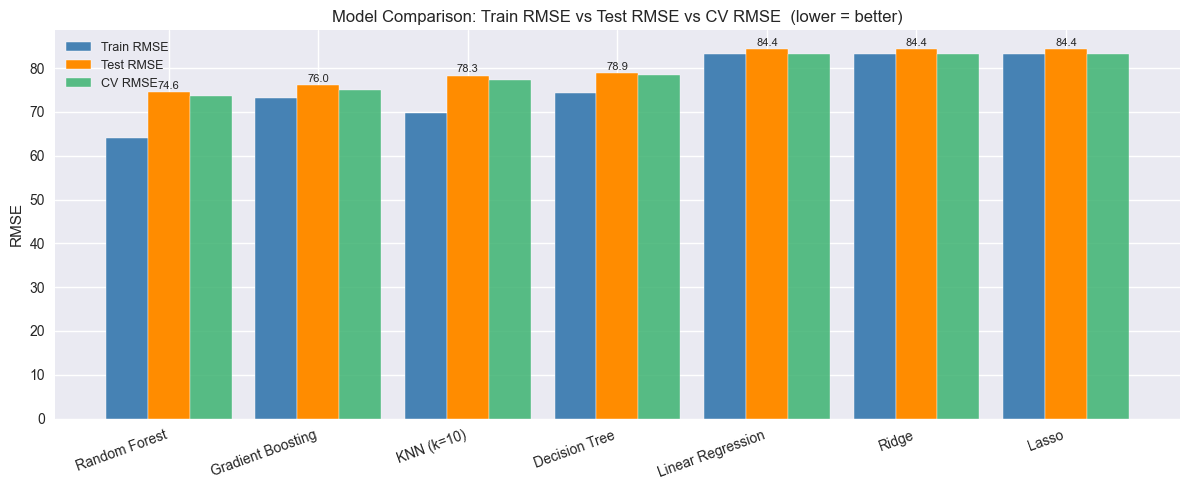

A large gap between Train RMSE and Test RMSE indicates overfitting.


In [18]:
# Plot 1: Train RMSE vs Test RMSE vs CV RMSE
fig, ax = plt.subplots(figsize=(12, 5))
x = np.arange(len(results_df))
w = 0.28

ax.bar(x - w, results_df['Train RMSE'], width=w, label='Train RMSE', color='steelblue',      edgecolor='white')
ax.bar(x,     results_df['Test RMSE'],  width=w, label='Test RMSE',  color='darkorange',     edgecolor='white')
ax.bar(x + w, results_df['CV RMSE'],    width=w, label='CV RMSE',    color='mediumseagreen', edgecolor='white', alpha=0.85)

ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('RMSE')
ax.set_title('Model Comparison: Train RMSE vs Test RMSE vs CV RMSE  (lower = better)', fontsize=12)
ax.legend(fontsize=9)

for bar in ax.patches[7:14]:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{bar.get_height():.1f}', ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()
print('A large gap between Train RMSE and Test RMSE indicates overfitting.')

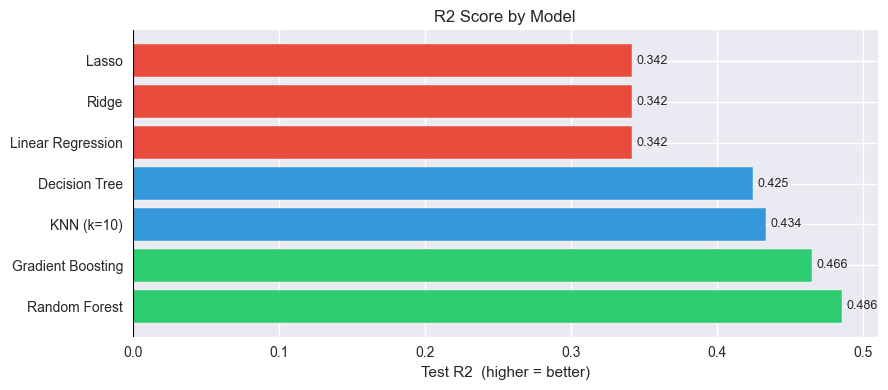

Green = R2 >= 0.45 | Blue = R2 >= 0.35 | Red = R2 < 0.35


In [19]:
# Plot 2: R2 by model
fig, ax = plt.subplots(figsize=(9, 4))
colors = ['#2ecc71' if v >= 0.45 else '#3498db' if v >= 0.35 else '#e74c3c'
          for v in results_df['Test R2']]
bars = ax.barh(results_df['Model'], results_df['Test R2'], color=colors, edgecolor='white')
ax.set_xlabel('Test R2  (higher = better)', fontsize=11)
ax.set_title('R2 Score by Model', fontsize=12)
ax.axvline(0, color='black', linewidth=0.8)
for bar, v in zip(bars, results_df['Test R2']):
    ax.text(v + 0.003, bar.get_y() + bar.get_height()/2,
            f'{v:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.show()
print('Green = R2 >= 0.45 | Blue = R2 >= 0.35 | Red = R2 < 0.35')

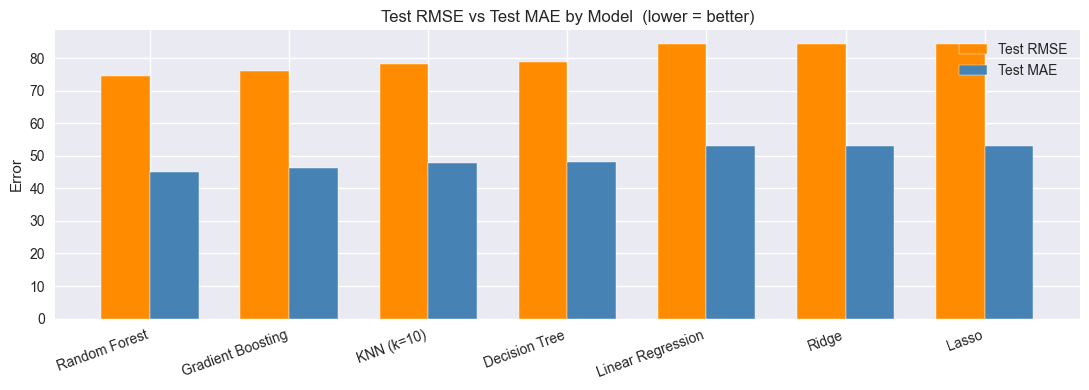

RMSE is always higher than MAE because it penalises large errors more heavily.


In [20]:
# Plot 3: Test RMSE vs Test MAE
fig, ax = plt.subplots(figsize=(11, 4))
x = np.arange(len(results_df))
w = 0.35
ax.bar(x - w/2, results_df['Test RMSE'], width=w, label='Test RMSE', color='darkorange', edgecolor='white')
ax.bar(x + w/2, results_df['Test MAE'],  width=w, label='Test MAE',  color='steelblue',  edgecolor='white')
ax.set_xticks(x)
ax.set_xticklabels(results_df['Model'], rotation=20, ha='right', fontsize=10)
ax.set_ylabel('Error')
ax.set_title('Test RMSE vs Test MAE by Model  (lower = better)', fontsize=12)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()
print('RMSE is always higher than MAE because it penalises large errors more heavily.')

---
## Step 11 — Best Model Deep Dive

In [21]:
best_name = results_df.iloc[0]['Model']
best_pipe = fitted[best_name]
best_pred = best_pipe.predict(X_test)
residuals = y_test.values - best_pred

print(f'Best Model    : {best_name}')
print(f'Test RMSE     : {np.sqrt(mean_squared_error(y_test, best_pred)):.2f}')
print(f'Test MAE      : {mean_absolute_error(y_test, best_pred):.2f}')
print(f'Test R2       : {r2_score(y_test, best_pred):.4f}')
print(f'Residual mean : {residuals.mean():.2f}  (near zero = model is unbiased)')
print(f'Residual std  : {residuals.std():.2f}')

Best Model    : Random Forest
Test RMSE     : 74.58
Test MAE      : 45.15
Test R2       : 0.4859
Residual mean : 0.32  (near zero = model is unbiased)
Residual std  : 74.58


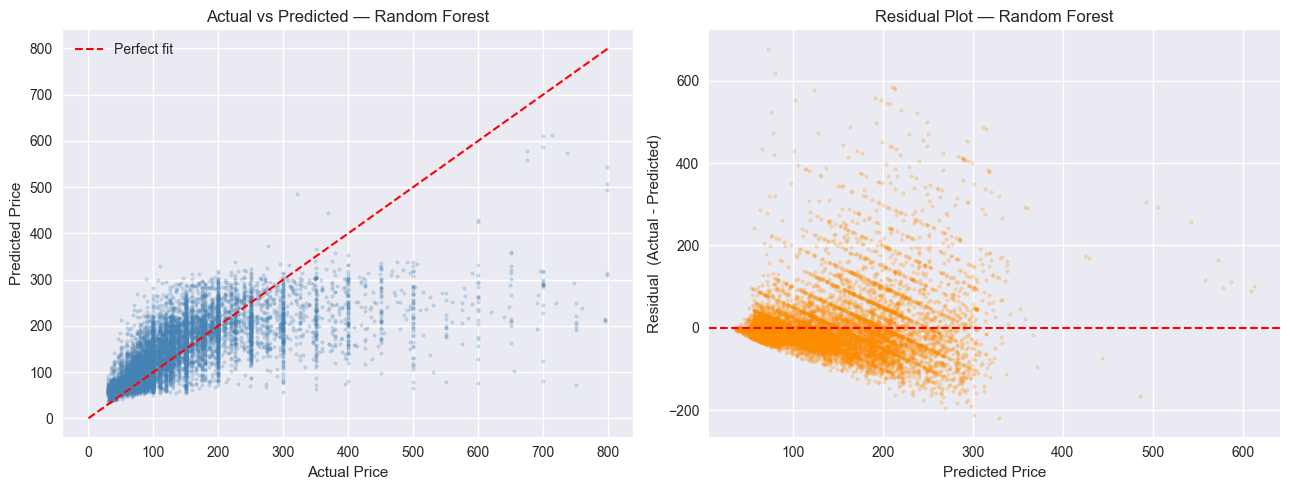

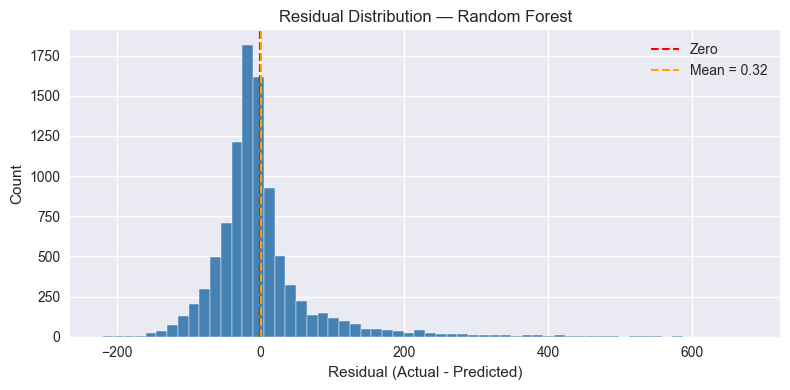

In [22]:
# Actual vs Predicted and Residual plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].scatter(y_test, best_pred, alpha=0.25, s=6, color='steelblue')
lim = max(y_test.max(), best_pred.max())
axes[0].plot([0, lim], [0, lim], 'r--', lw=1.5, label='Perfect fit')
axes[0].set_xlabel('Actual Price', fontsize=11)
axes[0].set_ylabel('Predicted Price', fontsize=11)
axes[0].set_title(f'Actual vs Predicted — {best_name}', fontsize=12)
axes[0].legend()

axes[1].scatter(best_pred, residuals, alpha=0.25, s=6, color='darkorange')
axes[1].axhline(0, color='red', ls='--', lw=1.5)
axes[1].set_xlabel('Predicted Price', fontsize=11)
axes[1].set_ylabel('Residual  (Actual - Predicted)', fontsize=11)
axes[1].set_title(f'Residual Plot — {best_name}', fontsize=12)

plt.tight_layout()
plt.show()

# Residual distribution
plt.figure(figsize=(8, 4))
plt.hist(residuals, bins=60, color='steelblue', edgecolor='white')
plt.axvline(0, color='red', ls='--', lw=1.5, label='Zero')
plt.axvline(residuals.mean(), color='orange', ls='--', lw=1.5,
            label=f'Mean = {residuals.mean():.2f}')
plt.xlabel('Residual (Actual - Predicted)')
plt.ylabel('Count')
plt.title(f'Residual Distribution — {best_name}', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

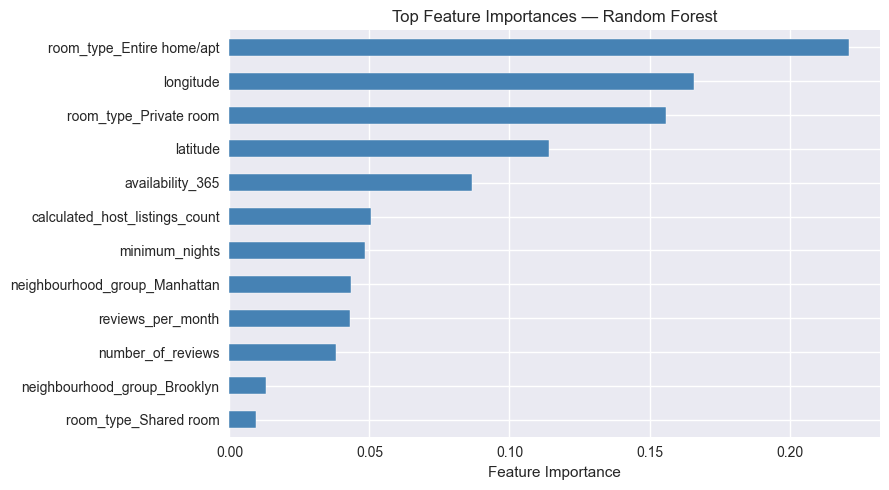

Top 5 features:
  room_type_Entire home/apt                     0.2212
  longitude                                     0.1660
  room_type_Private room                        0.1559
  latitude                                      0.1142
  availability_365                              0.0867


In [23]:
# Feature Importances
cat_pipeline = best_pipe.named_steps['preprocessor'].named_transformers_['cat']
ohe_names    = cat_pipeline.named_steps['encoder'].get_feature_names_out(CATEGORICAL_FEATURES)

all_names   = NUMERIC_FEATURES + list(ohe_names)
importances = best_pipe.named_steps['model'].feature_importances_

feat_imp = (pd.Series(importances, index=all_names)
              .sort_values(ascending=True)
              .tail(12))

plt.figure(figsize=(9, 5))
feat_imp.plot(kind='barh', color='steelblue', edgecolor='white')
plt.xlabel('Feature Importance')
plt.title(f'Top Feature Importances — {best_name}', fontsize=12)
plt.tight_layout()
plt.show()

print('Top 5 features:')
for fname, fval in feat_imp.iloc[::-1].head(5).items():
    print(f'  {fname:<45} {fval:.4f}')

---
## Step 12 — Conclusions

### Best Model: Random Forest

| Metric | Value |
|---|---|
| CV RMSE | 73.69 |
| Train RMSE | 64.09 |
| Test RMSE | 74.58 |
| Test MAE | 45.15 |
| Test R2 | 0.4859 |
| Train-Test Gap | 10.50 — small, no serious overfitting |
| Residual Mean | 0.32 — near zero, predictions are unbiased |

### Full Model Comparison

| Rank | Model | CV RMSE | Train RMSE | Test RMSE | Test MAE | Test R2 | Verdict |
|---|---|---|---|---|---|---|---|
| 1 | **Random Forest** | 73.69 | 64.09 | **74.58** | **45.15** | **0.486** | Best overall |
| 2 | Gradient Boosting | 75.09 | 73.11 | 76.04 | 46.34 | 0.466 | Strong second |
| 3 | KNN (k=10) | 77.30 | 69.80 | 78.27 | 47.88 | 0.434 | Good, stable |
| 4 | Decision Tree | 78.40 | 74.31 | 78.88 | 48.03 | 0.425 | Interpretable |
| 5 | Linear Regression | 83.31 | 83.26 | 84.37 | 53.18 | 0.342 | Baseline |
| 6 | Ridge | 83.31 | 83.26 | 84.37 | 53.17 | 0.342 | Same as Linear |
| 7 | Lasso | 83.32 | 83.28 | 84.39 | 53.11 | 0.342 | Weakest |

### Key Findings

**1. Random Forest is the best model.**
It has the lowest CV RMSE (73.69), lowest Test RMSE (74.58), and highest R2 (0.486). The Train-Test gap of 10.50 is small and acceptable — no serious overfitting. Residual mean of 0.32 confirms predictions are essentially unbiased.

**2. Non-linear models consistently outperform linear models.**
The correlation heatmap showed all numeric features have weak linear correlation with price (below 0.15). Tree-based models beat linear models by around 10 RMSE units. Price depends on complex non-linear interactions that linear models cannot capture.

**3. Linear models plateau around Test RMSE 84.**
Linear Regression, Ridge, and Lasso all give nearly identical results (RMSE ~84, R2 ~0.34). Ridge and Linear Regression are identical, meaning multicollinearity is not a problem in this feature set.

**4. Room type and location are the strongest predictors.**
Feature importance shows room_type (Entire home/apt), longitude, and latitude dominate. What you rent and where it is drives Airbnb price far more than operational details like reviews or availability.

**5. CV and test set rankings agree — results are reliable.**
Random Forest has both the lowest CV RMSE and the lowest Test RMSE. This consistency means the result is not due to a lucky data split.

### Why These Results Are Trustworthy
- No data leakage: all preprocessing inside Pipeline, fitted only on training data
- Raw price target: residual mean near zero — predictions are genuinely unbiased
- 5-fold CV: generalisation estimate does not depend on a single split
- Test set held out completely: final evaluation on truly unseen data
- All metrics in original price units: directly interpretable

### Limitations
All models plateau around R2 = 0.49. The remaining 51% of price variation is driven by listing quality factors not available as structured data — photo quality, review sentiment, host responsiveness, amenities, and proximity to landmarks.